# Retail Sales Forecasting & Business Insights using Python

## Project Objective

The objective of this project is to analyze Walmart retail sales data to identify trends, seasonal patterns, and business factors influencing weekly sales performance.

The project also applies machine learning models to forecast weekly sales using historical sales data and economic indicators.

## Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

## Dataset Features
- Store
- Weekly Sales
- Holiday Flag
- Temperature
- Fuel Price
- CPI
- Unemployment
- Date Features (Day, Month, Year)

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [24]:
df = pd.read_csv('Walmart_Store_sales.csv')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Data Understanding

Understanding the dataset structure, data types, missing values, and statistical summaries before performing analysis and modeling.

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [27]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

# Feature Engineering

Extracting Day, Month, and Year from the Date column for time-based trend analysis and forecasting.

In [28]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010


# Business Questions

1. How do weekly sales vary across months and years?
2. Do holiday periods impact retail sales?
3. How do economic indicators affect weekly sales?
4. Are there outliers affecting business performance?
5. Can machine learning accurately forecast weekly sales?

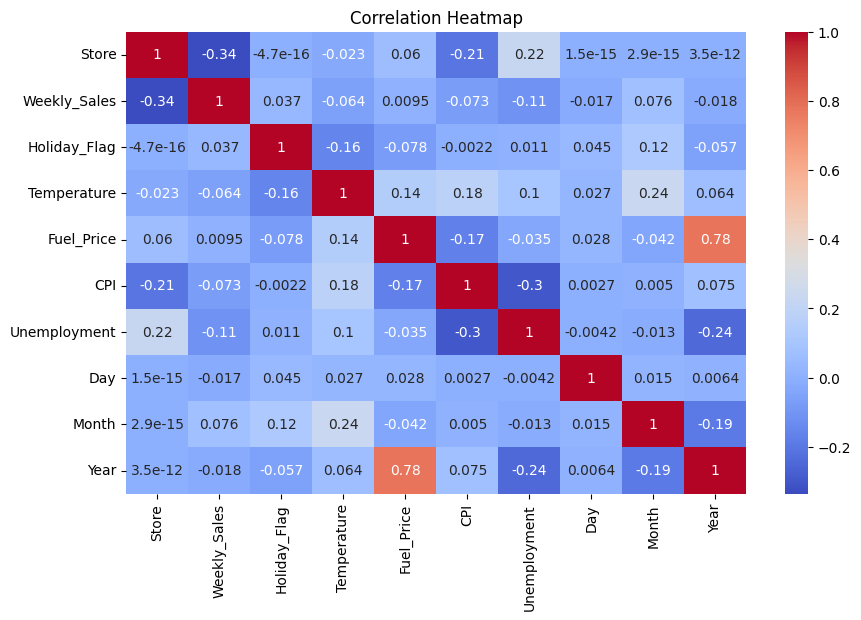

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Insight

The correlation analysis indicates that weekly sales are influenced by multiple business and economic factors rather than a single dominant variable. 

This suggests that machine learning models capable of handling complex relationships may perform better for forecasting.

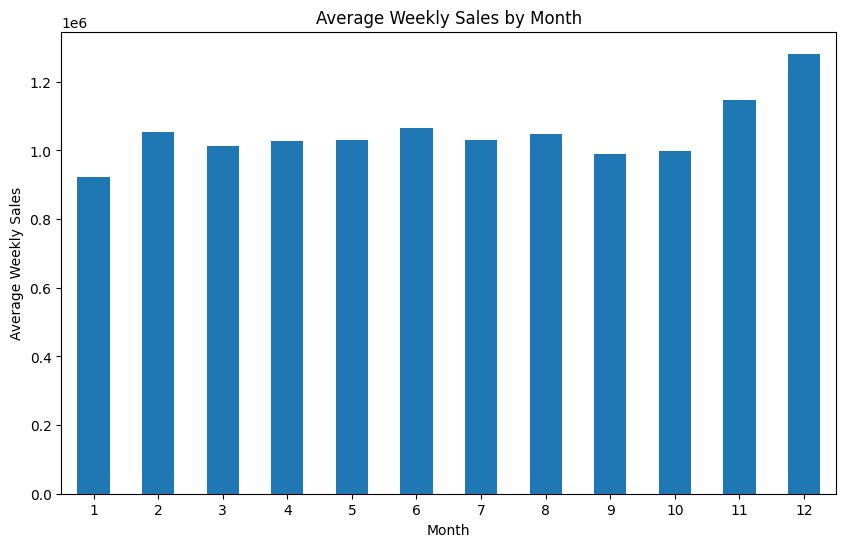

In [30]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10,6))

monthly_sales.plot(kind='bar')

plt.title('Average Weekly Sales by Month')

plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')

plt.xticks(rotation=0)

plt.show()

### Insight

Sales increased significantly during end-of-year months, indicating strong seasonal retail demand during holiday shopping periods.

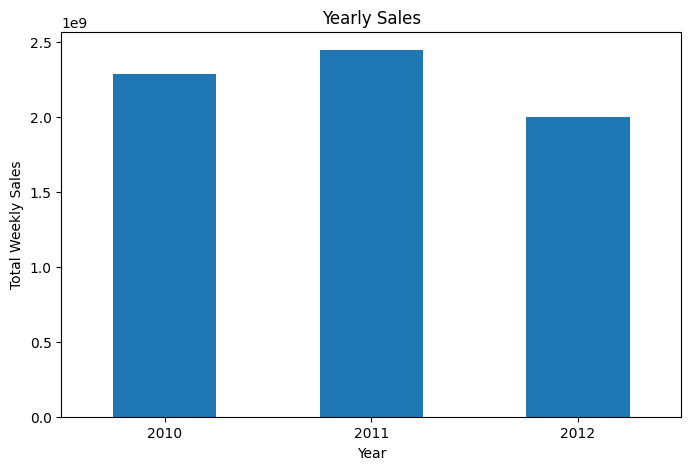

In [31]:
yearly_sales = df.groupby('Year')['Weekly_Sales'].sum()

plt.figure(figsize=(8,5))

yearly_sales.plot(kind='bar')

plt.title('Yearly Sales')

plt.xlabel('Year')
plt.ylabel('Total Weekly Sales')

plt.xticks(rotation=0)

plt.show()

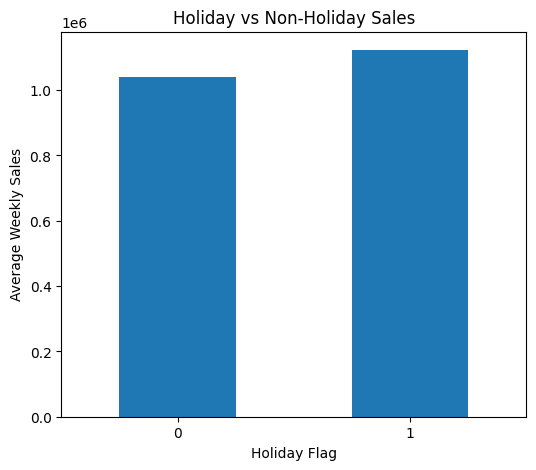

In [32]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

plt.figure(figsize=(6,5))

holiday_sales.plot(kind='bar')

plt.title('Holiday vs Non-Holiday Sales')

plt.xlabel('Holiday Flag')
plt.ylabel('Average Weekly Sales')

plt.xticks(rotation=0)

plt.show()

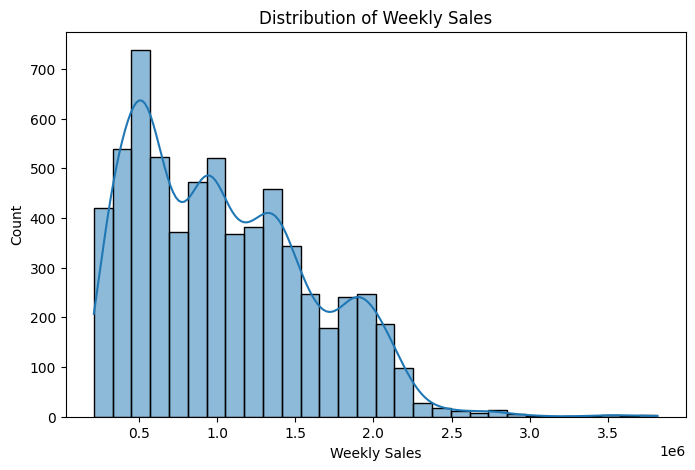

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df['Weekly_Sales'], bins=30, kde=True)

plt.title('Distribution of Weekly Sales')

plt.xlabel('Weekly Sales')

plt.show()

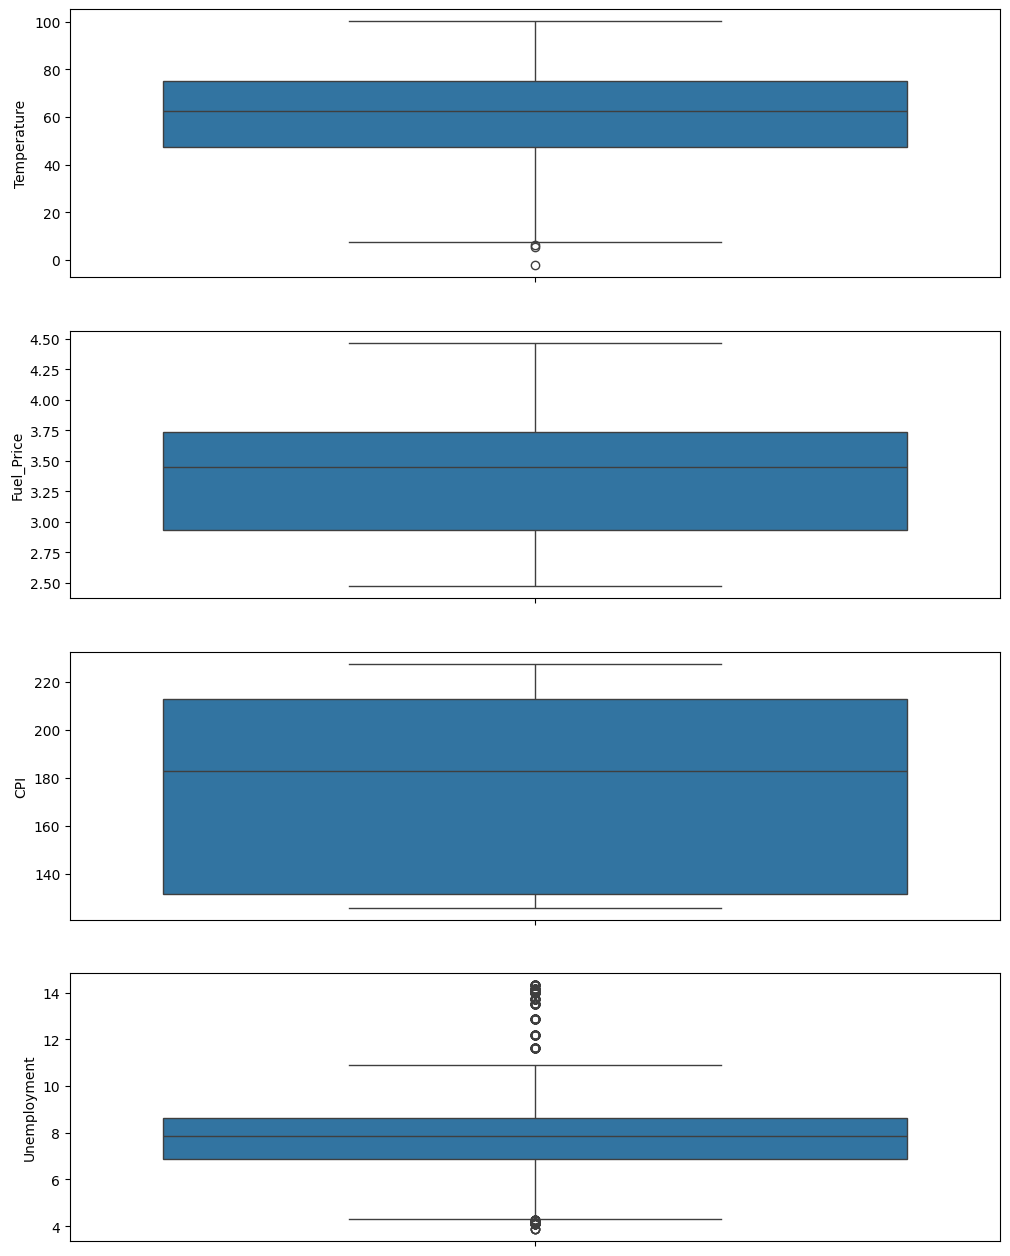

In [34]:
fig, axis = plt.subplots(4, figsize=(12,16))

columns = ['Temperature','Fuel_Price','CPI','Unemployment']

for i, column in enumerate(columns):
    
    sns.boxplot(df[column], ax=axis[i])

### Insight

Boxplots revealed the presence of outliers in Temperature and Unemployment variables. 

Outlier handling helps improve model stability and forecasting performance.

In [35]:
df = df[df['Temperature'] >= 8]

df = df[df['Unemployment'] <= 10.5]

df = df[df['Unemployment'] >= 4.7]

In [36]:
x = df[['Store',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Day',
        'Month',
        'Year']]

y = df['Weekly_Sales']

In [37]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
sc = StandardScaler()

x_train = sc.fit_transform(x_train)

x_test = sc.transform(x_test)

In [39]:
lr = LinearRegression()

lr.fit(x_train, y_train)

lr_y_pred = lr.predict(x_test)

print('* Linear Regression *\n')

print('Train Accuracy Score:',
      round(lr.score(x_train, y_train) * 100, 2), '%')

print('Test Accuracy Score:',
      round(r2_score(y_test, lr_y_pred) * 100, 2), '%')

* Linear Regression *

Train Accuracy Score: 13.08 %
Test Accuracy Score: 11.82 %


In [40]:
rfr = RandomForestRegressor()

rfr.fit(x_train, y_train)

rfr_y_pred = rfr.predict(x_test)

print('* Random Forest Regressor *\n')

print('Train Accuracy Score:',
      round(rfr.score(x_train, y_train) * 100, 2), '%')

print('Test Accuracy Score:',
      round(r2_score(y_test, rfr_y_pred) * 100, 2), '%')

* Random Forest Regressor *

Train Accuracy Score: 99.39 %
Test Accuracy Score: 96.24 %


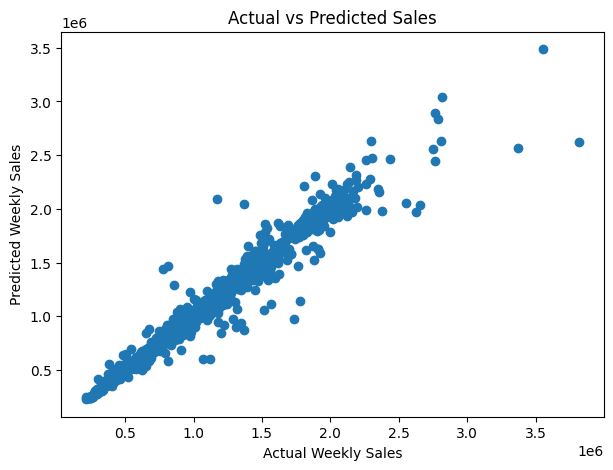

In [41]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, rfr_y_pred)

plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')

plt.title('Actual vs Predicted Sales')

plt.show()

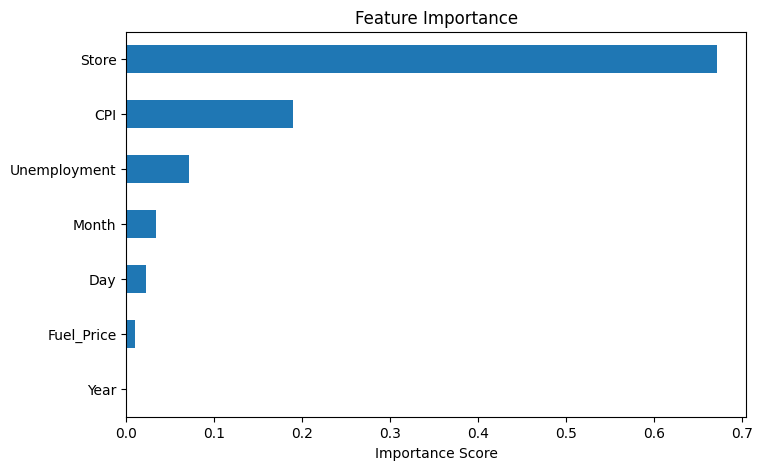

In [42]:
feature_importance = pd.Series(
    rfr.feature_importances_,
    index=x.columns
)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Feature Importance')

plt.xlabel('Importance Score')

plt.show()

## Key Business Insights

- Holiday periods showed higher average weekly sales compared to non-holiday periods.
- End-of-year months generated the strongest sales performance.
- Economic indicators such as CPI and unemployment showed moderate relationships with sales.
- Random Forest significantly outperformed Linear Regression in forecasting weekly sales.
- Store ID was the most influential feature in predicting weekly sales.

# Conclusion

This project analyzed Walmart retail sales data using exploratory data analysis and machine learning techniques.

Key findings:
- Retail sales showed strong seasonal patterns
- Holiday periods generated increased customer spending
- Economic indicators influenced sales trends moderately
- Random Forest significantly outperformed Linear Regression for forecasting

The project demonstrates how analytics and machine learning can support retail forecasting and business decision-making.